# Import libraries

In [ ]:
!pip install chess
import chess
import torch
import numpy as np
import pandas as pd
import pickle
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset
from torch.optim.lr_scheduler import ReduceLROnPlateau

In [ ]:
# make sure we can use cuda
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


# Chess board encoding


In [ ]:
def board_encode(board: chess.Board):
    # 6 piece types, 2 sides, 1 empty = 13
    # board dimensions = 8 x 8
    # encoded_board flatten to vector = 13 x 8 x 8 by 1
    encoded_board = np.zeros(13 * 64)

    # Map each piece to an index
    piece_to_index = {
        'r': 0, 'n': 1, 'b': 2, 'q': 3, 'k': 4, 'p': 5,
        'R': 6, 'N': 7, 'B': 8, 'Q': 9, 'K': 10, 'P': 11
    }
    EMPTY_INDEX = 12

    # Loop over all 64 squares
    for square in chess.SQUARES:
        # Get the piece at the current square
        piece = board.piece_at(square)

        # Determine which piece that is
        if piece is None:
            p_type = EMPTY_INDEX
        else:
            p_type = piece_to_index[piece.symbol()]

        # each piece occupy 8x8 numbers = 64
        # multiply by the piece type index + the offset (aka the square its at)
        """ eg:
         white queen = 9
         what the index of the white queen squares start at is 9 x 64 = encoded_board[576] until encoded_board[640]
         then we need to "activate" the bit where the queen is at. Lets say e4 so +10 giving us the formula:
         piece_index * 64 + offset.
        """
        index = p_type * 64 + square

        # Set this position to 1
        encoded_board[index] = 1.0

        # PLANE 13 add

    # encode to (13,8,8) for CNN, because of our offset this should line up perfectly (remove this for ANN)
    return torch.from_numpy(encoded_board.reshape(13,8,8)).to(torch.int8)

# This is for the 12 million datapoints dataset
def parse_eval(val):
    s = str(val).strip()
    if s.startswith('#'):
        # mate scores: "#3" or "#+3" = white wins, "#-2" = black wins
        return -10000.0 if s.startswith('#-') else 10000.0
    return float(s)

In [ ]:
board = chess.Board("r1bqkb1r/pppp1Qpp/2n2n2/4p3/2B1P3/8/PPPP1PPP/RNB1K1NR b KQkq - 0 4")
print(board)
encoded = board_encode(board)
print(encoded)
print(encoded.shape)  # should be (13, 8, 8) for CNN and (13 * 8 * 8) for ANN

r . b q k b . r
p p p p . Q p p
. . n . . n . .
. . . . p . . .
. . B . P . . .
. . . . . . . .
P P P P . P P P
R N B . K . N R
tensor([[[0, 0, 0, 0, 0, 0, 0, 0],
         [0, 0, 0, 0, 0, 0, 0, 0],
         [0, 0, 0, 0, 0, 0, 0, 0],
         [0, 0, 0, 0, 0, 0, 0, 0],
         [0, 0, 0, 0, 0, 0, 0, 0],
         [0, 0, 0, 0, 0, 0, 0, 0],
         [0, 0, 0, 0, 0, 0, 0, 0],
         [1, 0, 0, 0, 0, 0, 0, 1]],

        [[0, 0, 0, 0, 0, 0, 0, 0],
         [0, 0, 0, 0, 0, 0, 0, 0],
         [0, 0, 0, 0, 0, 0, 0, 0],
         [0, 0, 0, 0, 0, 0, 0, 0],
         [0, 0, 0, 0, 0, 0, 0, 0],
         [0, 0, 1, 0, 0, 1, 0, 0],
         [0, 0, 0, 0, 0, 0, 0, 0],
         [0, 0, 0, 0, 0, 0, 0, 0]],

        [[0, 0, 0, 0, 0, 0, 0, 0],
         [0, 0, 0, 0, 0, 0, 0, 0],
         [0, 0, 0, 0, 0, 0, 0, 0],
         [0, 0, 0, 0, 0, 0, 0, 0],
         [0, 0, 0, 0, 0, 0, 0, 0],
         [0, 0, 0, 0, 0, 0, 0, 0],
         [0, 0, 0, 0, 0, 0, 0, 0],
         [0, 0, 1, 0, 0, 1, 0, 0]],

        [[0, 0, 0, 0, 0, 0

# Loading data

In [ ]:
df = pd.read_csv('chessData.csv')

# Format the data
df["Evaluation"] = df["Evaluation"].apply(parse_eval)
df = df.dropna(subset=["Evaluation"]).reset_index(drop=True)

print(len(df))
df[:10]

12958035


,FEN,Evaluation
0,rnbqkbnr/pppppppp/8/8/4P3/8/PPPP1PPP/RNBQKBNR ...,-10.0
1,rnbqkbnr/pppp1ppp/4p3/8/4P3/8/PPPP1PPP/RNBQKBN...,56.0
2,rnbqkbnr/pppp1ppp/4p3/8/3PP3/8/PPP2PPP/RNBQKBN...,-9.0
3,rnbqkbnr/ppp2ppp/4p3/3p4/3PP3/8/PPP2PPP/RNBQKB...,52.0
4,rnbqkbnr/ppp2ppp/4p3/3p4/3PP3/8/PPPN1PPP/R1BQK...,-26.0
5,rnbqkb1r/ppp2ppp/4pn2/3p4/3PP3/8/PPPN1PPP/R1BQ...,50.0
6,rnbqkb1r/ppp2ppp/4pn2/3pP3/3P4/8/PPPN1PPP/R1BQ...,10.0
7,rnbqkb1r/pppn1ppp/4p3/3pP3/3P4/8/PPPN1PPP/R1BQ...,75.0
8,rnbqkb1r/pppn1ppp/4p3/3pP3/3P1P2/8/PPPN2PP/R1B...,52.0
9,rnbqkb1r/pp1n1ppp/4p3/2ppP3/3P1P2/8/PPPN2PP/R1...,52.0


In [ ]:
# this will be used to store eval and position (encoded as 1 hot matrixes)
positions = []
evaluations = []

# len of dataset
limit = min(4000000,len(df))

# loop thru the dataset
for i in range(limit):
    # encode all positions
    board = chess.Board(df["FEN"][i])
    encoded_board = board_encode(board)

    positions.append(encoded_board)

    # just copy paste over the eval values
    evaluations.append(df["Evaluation"][i])

# create a new dataframe
encoded_df = pd.DataFrame({
    "Position": positions,
    "Evaluation": evaluations
})

# save
with open('train_encoded.pkl', 'wb') as f:
    pickle.dump(encoded_df, f)

In [ ]:
# Sanity check
with open('train_encoded.pkl', 'rb') as f:
    df_encoded = pickle.load(f)

n = len(df_encoded)
df_encoded[:10]

,Position,Evaluation
0,"[[[tensor(0, dtype=torch.int8), tensor(0, dtyp...",-10.0
1,"[[[tensor(0, dtype=torch.int8), tensor(0, dtyp...",56.0
2,"[[[tensor(0, dtype=torch.int8), tensor(0, dtyp...",-9.0
3,"[[[tensor(0, dtype=torch.int8), tensor(0, dtyp...",52.0
4,"[[[tensor(0, dtype=torch.int8), tensor(0, dtyp...",-26.0
5,"[[[tensor(0, dtype=torch.int8), tensor(0, dtyp...",50.0
6,"[[[tensor(0, dtype=torch.int8), tensor(0, dtyp...",10.0
7,"[[[tensor(0, dtype=torch.int8), tensor(0, dtyp...",75.0
8,"[[[tensor(0, dtype=torch.int8), tensor(0, dtyp...",52.0
9,"[[[tensor(0, dtype=torch.int8), tensor(0, dtyp...",52.0


In [ ]:
split = int(n * 0.97)
batch_size = 256
# Split to training / testing sets
X_train = torch.stack(list(df_encoded["Position"][:split])).float()
y_train = torch.tensor(df_encoded["Evaluation"][:split].to_numpy(), dtype=torch.float32)

X_test = torch.stack(list(df_encoded["Position"][split:])).float()
y_test = torch.tensor(df_encoded["Evaluation"][split:].to_numpy(), dtype=torch.float32)

'''
# apply tanh "normalization"
y_train = torch.tanh(y_train / 400)
y_test = torch.tanh(y_test / 400)
'''
# create dataset and loader
dataset = TensorDataset(X_train, y_train)
loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

In [ ]:
# Sanity check
#print(X_train[0])
print(y_train[:10])

tensor([-10.,  56.,  -9.,  52., -26.,  50.,  10.,  75.,  52.,  52.])


# Make Network and Train it

In [ ]:

'''

model = nn.Sequential(
    nn.Linear(832, 256),
    nn.ReLU(),
    nn.Linear(256, 64),
    nn.ReLU(),
    nn.Linear(64, 8),
    nn.ReLU(),
    nn.Linear(8, 1)
)

'''

'''
  Main idea behind ResNet:
   + Input x goes through our usual CNN (except we add batch normalization) which is x -> conv -> batch normalization -> relu -> conv ...
   + Then the output of that layer has the input x itself added on
   + The sum is then passed to the next layer
   For a refresher check: https://www.youtube.com/watch?v=o_3mboe1jYI
'''
class ResBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        # define conv layers
        self.conv1 = nn.Conv2d(channels, channels, 3, padding=1)
        self.conv2 = nn.Conv2d(channels, channels, 3, padding=1)
        # define batch norm layers
        self.batch_norm1 = nn.BatchNorm2d(channels)
        self.batch_norm2 = nn.BatchNorm2d(channels)
        # define ReLU
        self.relu = nn.ReLU()

    def forward(self, x):
        # H(x)=F(x)+x where going from 1 layer to another is to still go through the forward pass but adding the input directly
        # this is because this formula is deriv from F(x) = H(x) - x, meaning it is trying to learn the difference between the output and input
        out = self.relu(self.batch_norm1(self.conv1(x)))
        #out = self.relu(self.conv1(x))

        # why adding another convolution onto it? => make this more meaningful and deeper. Most resblock uses this architecture but it is fine to remove conv2
        out = self.batch_norm2(self.conv2(out))
        #out = self.conv2(out)

        return self.relu(out + x)

class ChessNet(nn.Module):
    def __init__(self):
        super().__init__()

        # input layer
        self.input_conv = nn.Sequential(
            # 13 channels for each of the boards, 64 filters, size 3x3x1
            nn.Conv2d(13, 64, 3, padding=1),
            nn.ReLU(),
        )

        # make a res net (or tower of len 10)
        self.res_blocks = nn.Sequential(
            # 64 channels, 64 filters, size 3x3x1
            ResBlock(64),
            ResBlock(64),
            ResBlock(64),
            ResBlock(64),
            ResBlock(64),
        )

        # value head
        self.value_head = nn.Sequential(
            nn.Conv2d(64, 32, 1),
            nn.ReLU(),
            nn.Flatten(),
            # need to convert 64 x 32 to flat for a 1 layer ANN
            nn.Linear(32 * 8 * 8, 256),
            nn.ReLU(),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

        # create policy head in the future here

    def forward(self, x):
        x = self.input_conv(x)
        x = self.res_blocks(x)
        value = self.value_head(x)
        return value


model = ChessNet()
model.to(device)
print(model)

ChessNet(
  (input_conv): Sequential(
    (0): Conv2d(13, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
  )
  (res_blocks): Sequential(
    (0): ResBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (batch_norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (batch_norm2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU()
    )
    (1): ResBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (batch_norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (batch_norm2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU()
    )
    (2): ResBlock(


In [ ]:
# Define loss as MSE and use Adam instead of SGD
loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=0.002)

# update lr if plateau => lr * 0.2 if no improvement in 3 epochs
scheduler = ReduceLROnPlateau(optimizer, mode="min", patience=3, factor=0.2, min_lr=1e-5)

# training loop
losses = []
for epoch in range(40):
    print("Epoch: ", epoch)
    print("LR:", optimizer.param_groups[0]['lr'])
    epoch_loss = 0
    for X_batch, y_batch in loader:
        # send batches to device
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        y_hat = model(X_batch)
        loss = loss_fn(y_hat.view(-1), y_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(loader)
    print("avg_loss: ", avg_loss , "RMSE (in cp): ", np.sqrt(avg_loss))

    # if losses is not empty
    if losses:
      print(f"Improvement gain: {((losses[-1] - avg_loss) / losses[-1]):.4%}")

    losses.append(avg_loss)
    scheduler.step(avg_loss)



print("Final loss:", losses[-1])

Epoch:  0
LR: 0.001
avg_loss:  1290934.1428733424 RMSE (in cp):  1136.1928282089016
Epoch:  1
LR: 0.001
avg_loss:  1155600.43485477 RMSE (in cp):  1074.9885742903364
Improvement gain: 10.4834%
Epoch:  2
LR: 0.001
avg_loss:  1081776.3413099146 RMSE (in cp):  1040.0847760206448
Improvement gain: 6.3884%
Epoch:  3
LR: 0.001
avg_loss:  1024761.1626342202 RMSE (in cp):  1012.304876326406
Improvement gain: 5.2705%
Epoch:  4
LR: 0.001
avg_loss:  971248.5038590874 RMSE (in cp):  985.5194081595183
Improvement gain: 5.2220%
Epoch:  5
LR: 0.001
avg_loss:  925857.349386319 RMSE (in cp):  962.2148145743336
Improvement gain: 4.6735%
Epoch:  6
LR: 0.001
avg_loss:  885307.5161239444 RMSE (in cp):  940.907814891525
Improvement gain: 4.3797%
Epoch:  7
LR: 0.001
avg_loss:  849603.8012856065 RMSE (in cp):  921.7395517637325
Improvement gain: 4.0329%
Epoch:  8
LR: 0.001
avg_loss:  816073.1270370126 RMSE (in cp):  903.3676588394188
Improvement gain: 3.9466%
Epoch:  9
LR: 0.001
avg_loss:  786004.5245869276 R

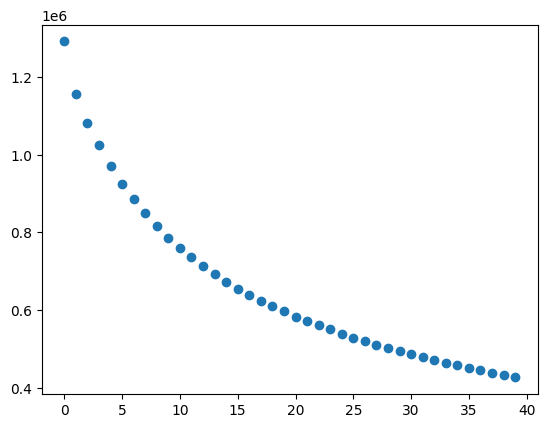

In [ ]:
plt.scatter(range(0, len(losses)), losses)
plt.show()

In [ ]:
# run model on test data
model.eval()  # set model to evaluation mode
y_hat_list = []

with torch.no_grad():  # no gradients needed
    # run the model for each batch
    for i in range(0, len(X_test), batch_size):
        X_batch = X_test[i:i+batch_size].to(device)
        y_hat_batch = model(X_batch)
        y_hat_list.append(y_hat_batch)

y_hat = torch.cat(y_hat_list)  # combine all predictions
loss = loss_fn(y_hat.view(-1), y_test.to(device))
print("Test Loss:", loss.item())

Test Loss: 1797720.75


In [ ]:
PATH = "model_res10.pth"
torch.save(model.state_dict(), PATH)